In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/cleaned_orders.csv")

In [31]:
df["revenue_per_order"] = df["price"] + df["freight_value"]

In [32]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M")

In [33]:
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])

df["delivery_days"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days

In [34]:
df["late_delivery_flag"] = (df["delivery_days"] > 7).astype(int)

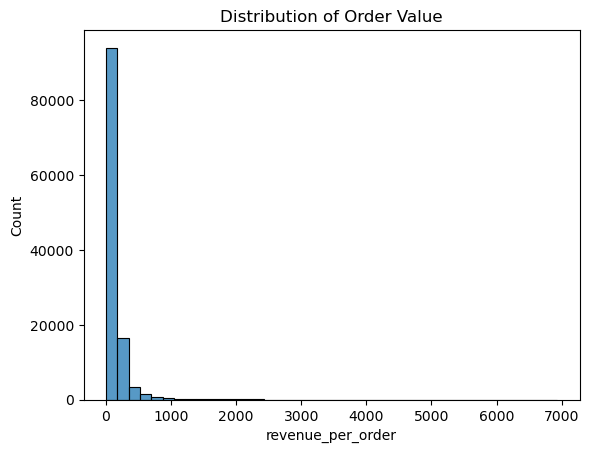

In [35]:
sns.histplot(df["revenue_per_order"], bins=40)
plt.title("Distribution of Order Value")
plt.show()

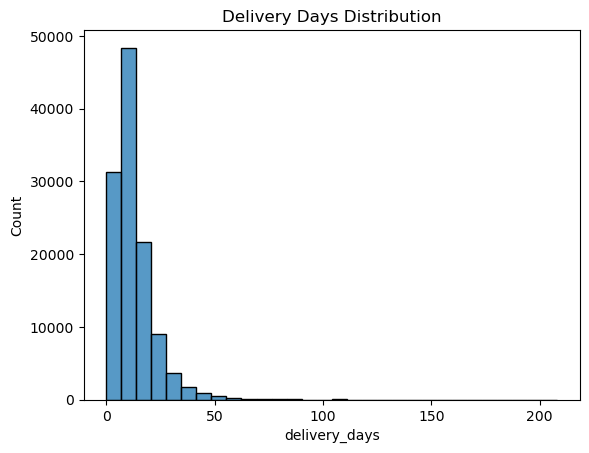

In [36]:
sns.histplot(df["delivery_days"], bins=30)
plt.title("Delivery Days Distribution")
plt.show()

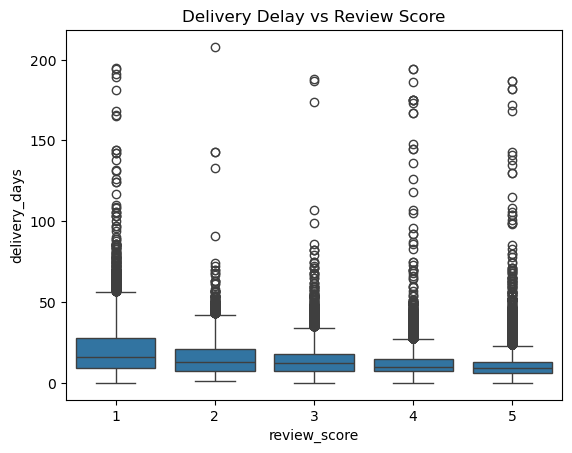

In [37]:
sns.boxplot(
x="review_score",
y="delivery_days",
data=df
)

plt.title("Delivery Delay vs Review Score")
plt.show()

In [38]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["order_month"] = df["order_purchase_timestamp"].dt.month

In [39]:
products = pd.read_csv("../data/raw/products.csv")

In [40]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value', 'review_id',
       'review_score', 'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'order_month',
       'delivery_days', 'late_delivery_flag', 'revenue_per_order'],
      dtype='object')

In [41]:
order_items = pd.read_csv("../data/raw/order_items.csv")

df = df.merge(order_items[["order_id","product_id","price","freight_value"]], 
              on="order_id", 
              how="left")

In [42]:
df = df.merge(
    order_items[["order_id","product_id","price","freight_value"]],
    on="order_id",
    how="left"
)

In [44]:
df["revenue_per_order"] = df["price"] + df["freight_value"]

In [45]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["order_month"] = df["order_purchase_timestamp"].dt.month

In [46]:
products = pd.read_csv("../data/raw/products.csv")

In [47]:
df = df.merge(
    products[["product_id","product_category_name"]],
    on="product_id",
    how="left"
)

In [48]:
df[["product_category_name","order_month","revenue_per_order"]].head()

,product_category_name,order_month,revenue_per_order
0,utilidades_domesticas,10,38.71
1,utilidades_domesticas,10,38.71
2,utilidades_domesticas,10,38.71
3,perfumaria,7,141.46
4,automotivo,8,179.12


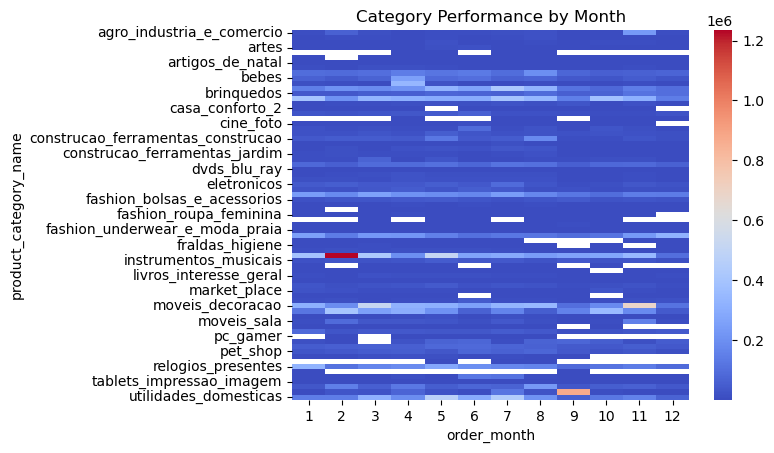

In [49]:
pivot = df.pivot_table(
index="product_category_name",
columns="order_month",
values="revenue_per_order",
aggfunc="sum"
)

sns.heatmap(pivot, cmap="coolwarm")

plt.title("Category Performance by Month")
plt.show()

### Insight 1
Late deliveries strongly correlate with low review scores.

### Insight 2
São Paulo generates the highest revenue but also experiences the most delivery delays.

### Insight 3
Electronics and furniture categories drive peak revenue during November–December.